In [33]:
#1. Load the data
import numpy as np
import pandas as pd
df = pd.read_csv('insurance2.csv')

df.head()

,age,sex,bmi,children,smoker,region,charges,insuranceclaim
0,19,0,27.900,0,1,3,16884.92400,1
1,18,1,33.770,1,0,2,1725.55230,1
2,28,1,33.000,3,0,2,4449.46200,0
3,33,1,22.705,0,0,1,21984.47061,0
4,32,1,28.880,0,0,1,3866.85520,1


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             1338 non-null   int64  
 1   sex             1338 non-null   int64  
 2   bmi             1338 non-null   float64
 3   children        1338 non-null   int64  
 4   smoker          1338 non-null   int64  
 5   region          1338 non-null   int64  
 6   charges         1338 non-null   float64
 7   insuranceclaim  1338 non-null   int64  
dtypes: float64(2), int64(6)
memory usage: 83.8 KB


In [35]:
df.describe()

,age,sex,bmi,children,smoker,region,charges,insuranceclaim
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,0.505232,30.663397,1.094918,0.204783,1.515695,13270.422265,0.585202
std,14.049960,0.500160,6.098187,1.205493,0.403694,1.104885,12110.011237,0.492871
min,18.000000,0.000000,15.960000,0.000000,0.000000,0.000000,1121.873900,0.000000
25%,27.000000,0.000000,26.296250,0.000000,0.000000,1.000000,4740.287150,0.000000
50%,39.000000,1.000000,30.400000,1.000000,0.000000,2.000000,9382.033000,1.000000
75%,51.000000,1.000000,34.693750,2.000000,0.000000,2.000000,16639.912515,1.000000
max,64.000000,1.000000,53.130000,5.000000,1.000000,3.000000,63770.428010,1.000000


In [36]:
df.corr()

,age,sex,bmi,children,smoker,region,charges,insuranceclaim
age,1.000000,-0.020856,0.109272,0.042469,-0.025019,0.002127,0.299008,0.113723
sex,-0.020856,1.000000,0.046371,0.017163,0.076185,0.004588,0.057292,0.031565
bmi,0.109272,0.046371,1.000000,0.012759,0.003750,0.157566,0.198341,0.384198
children,0.042469,0.017163,0.012759,1.000000,0.007673,0.016569,0.067998,-0.409526
smoker,-0.025019,0.076185,0.003750,0.007673,1.000000,-0.002181,0.787251,0.333261
region,0.002127,0.004588,0.157566,0.016569,-0.002181,1.000000,-0.006208,0.020891
charges,0.299008,0.057292,0.198341,0.067998,0.787251,-0.006208,1.000000,0.309418
insuranceclaim,0.113723,0.031565,0.384198,-0.409526,0.333261,0.020891,0.309418,1.000000


In [37]:
# important libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [38]:
# 2. Split features & target
X = df.drop('insuranceclaim', axis=1)
y = df['insuranceclaim']

In [39]:
# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [40]:
# 4. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
# 5. Train Logistic Regression
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [42]:
# 6. Predictions
y_pred = model.predict(X_test_scaled)

In [43]:
# 7. Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8619402985074627

Confusion Matrix:
 [[ 92  15]
 [ 22 139]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.86      0.83       107
           1       0.90      0.86      0.88       161

    accuracy                           0.86       268
   macro avg       0.85      0.86      0.86       268
weighted avg       0.86      0.86      0.86       268



Multi class classification using Fashion-MNIST dataset

In [44]:
!pip install tensorflow

In [45]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

In [46]:
(x_train,y_train),(x_test,y_test)=fashion_mnist.load_data()

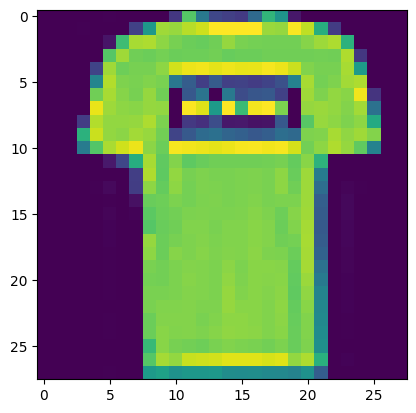

In [47]:
import matplotlib.pyplot as plt
plt.imshow(x_train[1])

In [48]:
x_train=x_train/255.0
x_test=x_test/255.0

In [49]:
x_train=x_train.reshape(-1,28*28)
x_test=x_test.reshape(-1,28*28)

In [50]:
x_train.shape

(60000, 784)

In [51]:
y_train.shape

(60000,)

In [52]:
model=tf.keras.models.Sequential()

In [53]:
model.add(tf.keras.layers.Dense(units=128,activation='relu',input_shape=(784,)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [54]:
model.add(tf.keras.layers.Dense(units=64,activation='relu'))

In [55]:
model.add(tf.keras.layers.Dense(units=32,activation='relu'))

In [56]:
model.add(tf.keras.layers.Dense(units=10,activation='softmax'))

In [57]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['sparse_categorical_crossentropy'])

In [58]:
model.fit(x_train,y_train,epochs=20)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 13ms/step - loss: 0.6658 - sparse_categorical_crossentropy: 0.6658
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step - loss: 0.3802 - sparse_categorical_crossentropy: 0.3802
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.3366 - sparse_categorical_crossentropy: 0.3366
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.3133 - sparse_categorical_crossentropy: 0.3133
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.2958 - sparse_categorical_crossentropy: 0.2958
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.2897 - sparse_categorical_crossentropy: 0.2897
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.2735 - sparse_categorical_crossentropy: 0.2735
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.2594 - sparse_categorical_crossentropy: 0.2594
Epoch 9/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.2520 - sparse_categorical_crossentropy: 0.252

In [60]:
#Evaluation metrics
test_loss,test_accuracy=model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3746 - sparse_categorical_crossentropy: 0.3746


In [64]:
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np

# Get predictions for the Fashion-MNIST model
predictions = model.predict(x_test)
y_pred_fashion = np.argmax(predictions, axis=1)

# Calculate accuracy
accuracy_fashion = accuracy_score(y_test, y_pred_fashion)
print(f"Fashion-MNIST Model Accuracy: {accuracy_fashion:.4f}")

# Calculate confusion matrix
confusion_mat_fashion = confusion_matrix(y_test, y_pred_fashion)
print("\nFashion-MNIST Model Confusion Matrix:")
print(confusion_mat_fashion)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Fashion-MNIST Model Accuracy: 0.8852

Fashion-MNIST Model Confusion Matrix:
[[807   0  23  37   1   1 119   0  12   0]
 [  4 972   1  16   3   0   3   0   1   0]
 [ 12   1 823  11  53   0  99   0   1   0]
 [ 13   7  10 918  22   1  25   0   4   0]
 [  0   1 114  44 721   0 118   0   2   0]
 [  0   0   0   1   0 960   0  27   1  11]
 [ 97   1  65  32  28   0 772   0   5   0]
 [  0   0   0   0   0   6   0 986   0   8]
 [  4   0   5   2   1   4   8   3 973   0]
 [  0   0   0   1   0   8   1  70   0 920]]
